# Прогнозирование почасовой выработки ВЭС

Готовый pipeline для первой задачи:

1. загрузка исторических данных из CSV/XLSX;
2. аудит качества и поиск пропусков;
3. очистка физических ошибок и дубликатов;
4. преобразование 10-минутных измерений в почасовые;
5. разведочный анализ данных;
6. построение честных временных выборок;
7. сравнение двух базовых алгоритмов с **CatBoost**;
8. оценка качества и анализ ошибок;
9. сохранение модели и функции прогноза по будущей погоде.

> **Цель:** `Нормализованная активная мощность`. Почасовая нормализованная мощность — среднее доступных 10-минутных значений внутри часа. Если известна установленная мощность ВЭС, почасовая энергия равна `normalized_power × installed_capacity_mw` и измеряется в МВт·ч.

> **Честность эксперимента:** модель использует погоду соответствующего прогнозного часа. Для промышленной оценки её нужно обучать/проверять на архивных погодных прогнозах, реально доступных в момент выпуска прогноза. Наблюдавшаяся погода даёт оптимистичную оценку качества.


## 0. Установка библиотек

Раскомментируйте следующую строку только при первом запуске. После установки перезапустите kernel.


In [4]:
# %pip install -q pandas numpy matplotlib seaborn scikit-learn catboost openpyxl joblib


## 1. Импорты и настройки

Укажите путь к файлу в `DATA_PATH`. Для проверки ноутбука без файла можно временно включить `USE_DEMO_DATA = True`.


In [5]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

try:
    from catboost import CatBoostRegressor
except ImportError as exc:
    raise ImportError(
        "CatBoost не установлен. Выполните ячейку установки выше и перезапустите kernel."
    ) from exc

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42

# ------------------------- НАСТРОЙКИ ПОЛЬЗОВАТЕЛЯ -------------------------
DATA_PATH = Path("C:/python_projects/hack-292e04fe-neurohub/dataset_energy.csv")   # CSV или XLSX
USE_DEMO_DATA = False                    # True — запустить на синтетическом примере
CSV_SEPARATOR = None                     # None = определить автоматически
CSV_ENCODING = "utf-8"                  # при необходимости: "utf-8-sig" или "cp1251"

INSTALLED_CAPACITY_MW = None             # например, 50.0; None = прогноз только в долях 0...1
MIN_HOURLY_COVERAGE = 0.67               # минимум исходных точек внутри часа
INTERPOLATE_WEATHER_LIMIT_HOURS = 2      # только короткие разрывы погоды
DROP_STATISTICAL_ANOMALIES = False       # обычно False: остановки ВЭС могут быть реальными
RUN_WALK_FORWARD = False                 # True = дополнительная, более долгая кросс-валидация

ARTIFACT_DIR = Path("model_artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


## 2. Вспомогательные функции загрузки и распознавания столбцов

Ноутбук понимает русские названия из примера, а также распространённые английские варианты. Если автоматическое распознавание не сработает, заполните `MANUAL_COLUMNS`.


In [6]:
MANUAL_COLUMNS = {
    "datetime": None,       # например: "Статистическое время"
    "wind_speed": None,     # например: "Средняя скорость ветра(m/s)"
    "target_power": None,   # например: "Нормализованная активная мощность"
    "temperature": None,    # например: "Средняя температура окружающей среды(°C)"
}

COLUMN_ALIASES = {
    "datetime": [
        "статистическое время", "время", "дата", "datetime", "timestamp", "date_time", "time"
    ],
    "wind_speed": [
        "средняя скорость ветра", "скорость ветра", "wind speed", "wind_speed", "windspeed"
    ],
    "target_power": [
        "нормализованная активная мощность", "активная мощность", "normalized active power",
        "normalized_power", "target_power", "power"
    ],
    "temperature": [
        "средняя температура окружающей среды", "температура", "ambient temperature",
        "temperature", "temperature_2m", "temp"
    ],
}


def normalize_name(value):
    return " ".join(str(value).strip().lower().replace("_", " ").split())


def find_column(columns, aliases):
    normalized = {col: normalize_name(col) for col in columns}
    aliases = [normalize_name(x) for x in aliases]

    # Сначала точное совпадение, затем совпадение по подстроке.
    for col, name in normalized.items():
        if name in aliases:
            return col
    for alias in aliases:
        for col, name in normalized.items():
            if alias in name:
                return col
    return None


def load_table(path, separator=None, encoding="utf-8"):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Файл не найден: {path.resolve()}\n"
            "Поместите CSV/XLSX рядом с ноутбуком или измените DATA_PATH."
        )

    suffix = path.suffix.lower()
    if suffix in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    if suffix in {".csv", ".txt"}:
        kwargs = {"encoding": encoding}
        if separator is None:
            kwargs.update({"sep": None, "engine": "python"})
        else:
            kwargs["sep"] = separator
        return pd.read_csv(path, **kwargs)
    raise ValueError("Поддерживаются форматы CSV, TXT, XLSX и XLS.")


def generate_demo_data(days=540, seed=42):
    '''Синтетические 10-минутные данные только для проверки выполнения ноутбука.'''
    rng = np.random.default_rng(seed)
    dt = pd.date_range("2024-01-01", periods=days * 24 * 6, freq="10min")
    seasonal = 1.3 * np.sin(2 * np.pi * dt.dayofyear.to_numpy() / 365.25)
    intraday = 0.5 * np.sin(2 * np.pi * dt.hour.to_numpy() / 24)
    wind = np.clip(7 + seasonal + intraday + rng.normal(0, 1.8, len(dt)), 0, 25)
    temp = 9 + 14 * np.sin(2 * np.pi * (dt.dayofyear.to_numpy() - 170) / 365.25)
    temp += rng.normal(0, 2.2, len(dt))

    # Упрощённая S-образная кривая мощности с шумом.
    power = 1 / (1 + np.exp(-(wind - 7.5) / 1.5))
    power = np.clip(power + rng.normal(0, 0.035, len(dt)), 0, 1)

    frame = pd.DataFrame({
        "ID": np.arange(1, len(dt) + 1),
        "Статистическое время": dt,
        "Средняя скорость ветра(m/s)": wind,
        "Нормализованная активная мощность": power,
        "Средняя температура окружающей среды(°C)": temp,
    })

    # Несколько дефектов для демонстрации аудита.
    missing_idx = rng.choice(len(frame), size=max(10, len(frame) // 300), replace=False)
    frame.loc[missing_idx[: len(missing_idx) // 2], "Средняя скорость ветра(m/s)"] = np.nan
    frame.loc[missing_idx[len(missing_idx) // 2 :], "Нормализованная активная мощность"] = np.nan
    return frame


raw = generate_demo_data() if USE_DEMO_DATA else load_table(
    DATA_PATH, separator=CSV_SEPARATOR, encoding=CSV_ENCODING
)

# Удаляем технический индекс, часто появляющийся после сохранения pandas.
unnamed = [c for c in raw.columns if normalize_name(c).startswith("unnamed")]
raw = raw.drop(columns=unnamed, errors="ignore")

resolved = {}
for canonical, aliases in COLUMN_ALIASES.items():
    resolved[canonical] = MANUAL_COLUMNS[canonical] or find_column(raw.columns, aliases)

missing_columns = [name for name, source in resolved.items() if source is None]
if missing_columns:
    raise ValueError(
        "Не удалось распознать поля: " + ", ".join(missing_columns) +
        ". Заполните MANUAL_COLUMNS. Доступные столбцы: " + str(list(raw.columns))
    )

df = raw.rename(columns={source: canonical for canonical, source in resolved.items()})[
    ["datetime", "wind_speed", "target_power", "temperature"]
].copy()

df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
for col in ["wind_speed", "target_power", "temperature"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"Исходный размер: {raw.shape[0]:,} строк × {raw.shape[1]} столбцов")
print("Распознанные поля:")
display(pd.Series(resolved, name="исходный столбец").to_frame())
display(df.head())


Исходный размер: 149,499 строк × 5 столбцов
Распознанные поля:


,исходный столбец
datetime,Статистическое время
wind_speed,Средняя скорость ветра(m/s)
target_power,Нормализованная активная мощность
temperature,Средняя температура окружающей среды(°C)


,datetime,wind_speed,target_power,temperature
0,2023-03-11 00:00:00,6.6200,0.3700,15.5200
1,2023-03-11 00:10:00,6.7000,0.3900,15.3800
2,2023-03-11 00:20:00,7.1400,0.4400,15.4300
3,2023-03-11 00:30:00,7.8200,0.5000,15.4100
4,2023-03-11 00:40:00,7.6200,0.4900,15.4200


## 3. Первичный аудит качества

Сначала фиксируем состояние исходного набора до любых исправлений.


,dtype,missing_count,missing_pct,unique
datetime,datetime64[us],0,0.0000,149499
wind_speed,float64,0,0.0000,1819
target_power,float64,0,0.0000,101
temperature,float64,0,0.0000,5913


,Количество
Полные дубликаты,0
Строки с повторяющимся временем,0
Некорректная дата,0
Скорость ветра < 0,0
Мощность < 0,0
Мощность > 1,0
"Температура вне [-70, 60] °C",0


Медианный интервал: 0 days 00:10:00
Период данных: 2023-03-11 00:00:00 — 2026-01-31 23:50:00


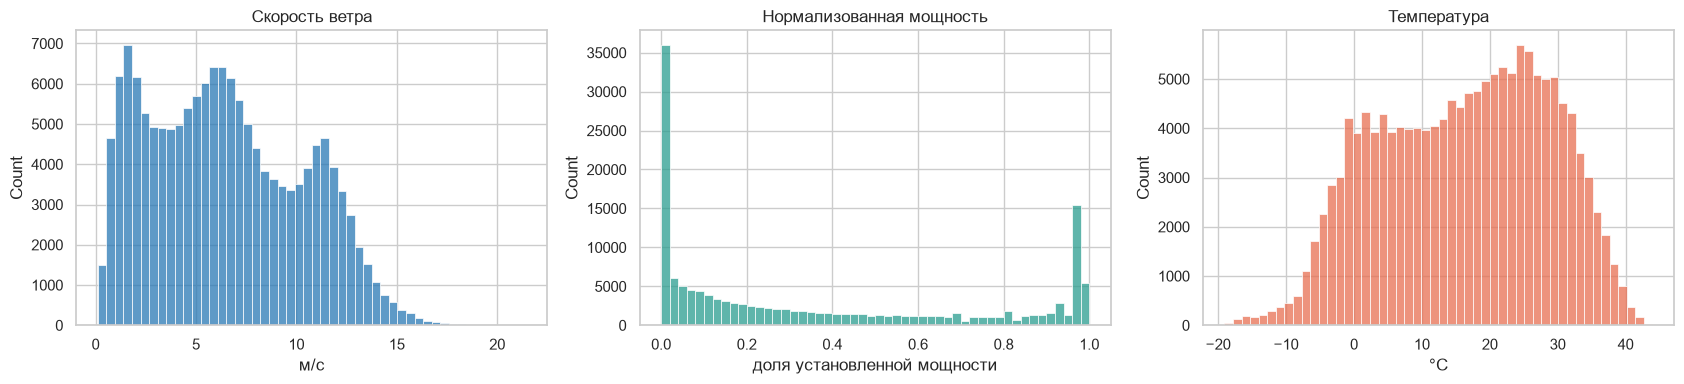

In [7]:
def quality_report(frame):
    report = pd.DataFrame({
        "dtype": frame.dtypes.astype(str),
        "missing_count": frame.isna().sum(),
        "missing_pct": (frame.isna().mean() * 100).round(3),
        "unique": frame.nunique(dropna=True),
    })
    return report


display(quality_report(df))

duplicate_rows = int(df.duplicated().sum())
duplicate_timestamps = int(df["datetime"].duplicated(keep=False).sum())

physical_checks = pd.Series({
    "Полные дубликаты": duplicate_rows,
    "Строки с повторяющимся временем": duplicate_timestamps,
    "Некорректная дата": int(df["datetime"].isna().sum()),
    "Скорость ветра < 0": int((df["wind_speed"] < 0).sum()),
    "Мощность < 0": int((df["target_power"] < 0).sum()),
    "Мощность > 1": int((df["target_power"] > 1).sum()),
    "Температура вне [-70, 60] °C": int(((df["temperature"] < -70) | (df["temperature"] > 60)).sum()),
})
display(physical_checks.to_frame("Количество"))

valid_times = df["datetime"].dropna().sort_values().drop_duplicates()
time_step = valid_times.diff().dropna().median()
print(f"Медианный интервал: {time_step}")
print(f"Период данных: {valid_times.min()} — {valid_times.max()}")

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
sns.histplot(df["wind_speed"], bins=50, ax=axes[0], color="#2878B5")
axes[0].set(title="Скорость ветра", xlabel="м/с")
sns.histplot(df["target_power"], bins=50, ax=axes[1], color="#2A9D8F")
axes[1].set(title="Нормализованная мощность", xlabel="доля установленной мощности")
sns.histplot(df["temperature"], bins=50, ax=axes[2], color="#E76F51")
axes[2].set(title="Температура", xlabel="°C")
plt.tight_layout()
plt.show()


## 4. Очистка и почасовая агрегация

Физически невозможные значения заменяются пропусками. Повторные временные метки объединяются средним. Для часа требуется не менее заданной доли исходных измерений. Погодные признаки разрешено интерполировать только на коротких разрывах; целевая мощность не интерполируется.


In [8]:
clean = df.copy()
clean = clean.dropna(subset=["datetime"])
clean = clean.drop_duplicates()

# Физические ограничения. Верхнюю границу ветра 75 м/с используем как защиту от ошибок единиц/ввода.
clean.loc[(clean["wind_speed"] < 0) | (clean["wind_speed"] > 75), "wind_speed"] = np.nan
clean.loc[(clean["target_power"] < 0) | (clean["target_power"] > 1), "target_power"] = np.nan
clean.loc[(clean["temperature"] < -70) | (clean["temperature"] > 60), "temperature"] = np.nan

# Одно наблюдение на временную метку.
clean = (
    clean.groupby("datetime", as_index=False)[["wind_speed", "target_power", "temperature"]]
    .mean()
    .sort_values("datetime")
)

median_minutes = clean["datetime"].diff().dropna().median().total_seconds() / 60
expected_per_hour = max(1, int(round(60 / median_minutes))) if median_minutes > 0 else 1
min_points = max(1, int(np.ceil(expected_per_hour * MIN_HOURLY_COVERAGE)))

indexed = clean.set_index("datetime")
hourly_mean = indexed.resample("1h").mean()
hourly_count = indexed.resample("1h").count().add_suffix("_count")
hourly = hourly_mean.join(hourly_count)

# Недостаточно представленные часы не получают искусственную цель.
hourly.loc[hourly["target_power_count"] < min_points, "target_power"] = np.nan
hourly.loc[hourly["wind_speed_count"] < min_points, "wind_speed"] = np.nan
hourly.loc[hourly["temperature_count"] < min_points, "temperature"] = np.nan

# Только погодные признаки и только короткие внутренние разрывы.
for col in ["wind_speed", "temperature"]:
    hourly[col] = hourly[col].interpolate(
        method="time", limit=INTERPOLATE_WEATHER_LIMIT_HOURS, limit_area="inside"
    )

hourly["coverage"] = hourly["target_power_count"] / expected_per_hour

# Hampel-подобный флаг: локальное отклонение от медианы. По умолчанию строки не удаляются.
rolling_median = hourly["target_power"].rolling(7, center=True, min_periods=4).median()
abs_deviation = (hourly["target_power"] - rolling_median).abs()
rolling_mad = abs_deviation.rolling(7, center=True, min_periods=4).median()
threshold = 4.0 * 1.4826 * rolling_mad.replace(0, np.nan)
hourly["power_hampel_anomaly"] = abs_deviation > threshold

if DROP_STATISTICAL_ANOMALIES:
    hourly.loc[hourly["power_hampel_anomaly"], "target_power"] = np.nan

if INSTALLED_CAPACITY_MW is not None:
    # Средняя мощность за час × 1 час = энергия в МВт·ч.
    hourly["energy_mwh"] = hourly["target_power"] * float(INSTALLED_CAPACITY_MW)

print(f"Ожидалось измерений в час: {expected_per_hour}; минимум принято: {min_points}")
print(f"Получено почасовых строк: {len(hourly):,}")
print(f"Часов без целевой мощности: {hourly['target_power'].isna().sum():,}")
print(f"Статистически подозрительных часов: {hourly['power_hampel_anomaly'].sum():,}")
display(hourly.head())


Ожидалось измерений в час: 6; минимум принято: 5
Получено почасовых строк: 25,392
Часов без целевой мощности: 522
Статистически подозрительных часов: 1,409


,wind_speed,target_power,temperature,wind_speed_count,target_power_count,temperature_count,coverage,power_hampel_anomaly
datetime,,,,,,,,
2023-03-11 00:00:00,7.0267,0.4200,15.3533,6,6,6,1.0000,False
2023-03-11 01:00:00,6.1950,0.3083,14.2383,6,6,6,1.0000,False
2023-03-11 02:00:00,7.1433,0.4317,13.5733,6,6,6,1.0000,False
2023-03-11 03:00:00,8.8783,0.6233,12.5567,6,6,6,1.0000,False
2023-03-11 04:00:00,11.7150,0.9450,11.3200,6,6,6,1.0000,False


## 5. Разведочный анализ почасовых данных

Особое внимание уделяется физической связи «ветер → мощность», сезонности и временным разрывам.


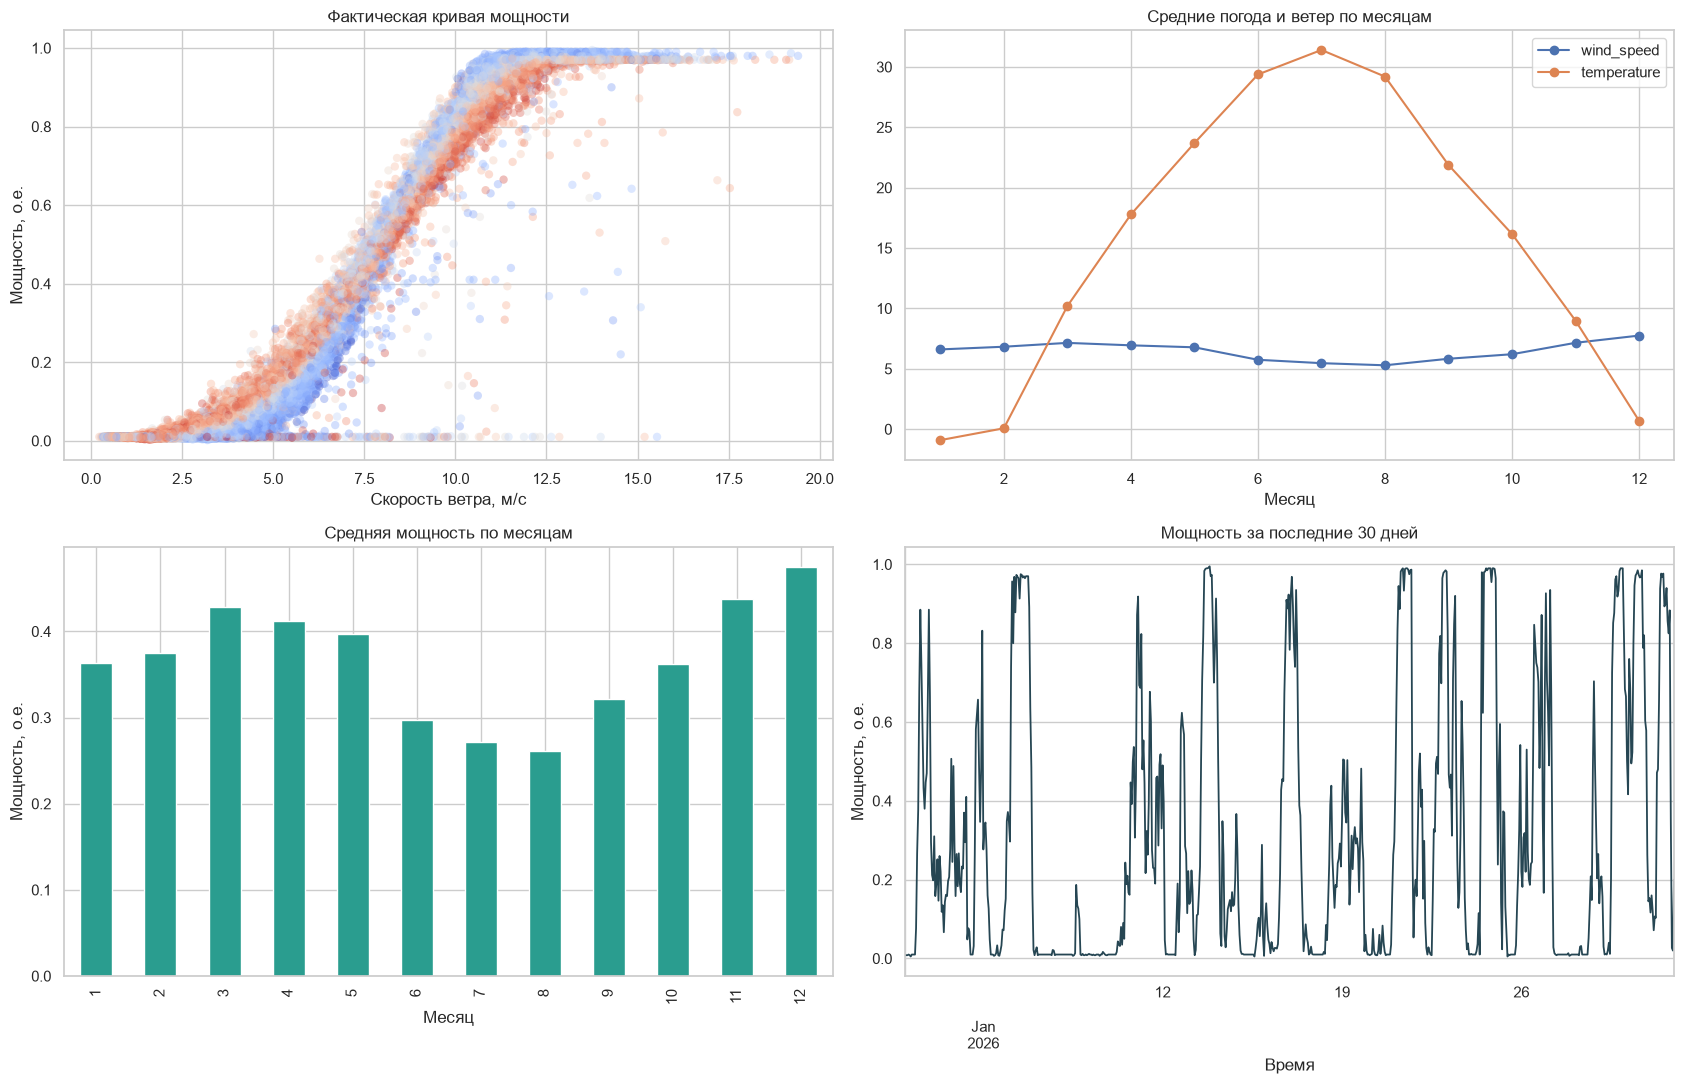

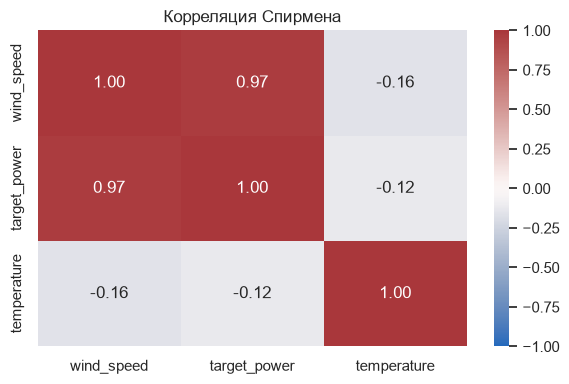

In [9]:
eda = hourly.dropna(subset=["wind_speed", "target_power", "temperature"]).copy()

fig, axes = plt.subplots(2, 2, figsize=(17, 11))

sample_n = min(25_000, len(eda))
sample = eda.sample(sample_n, random_state=RANDOM_STATE) if sample_n else eda
sns.scatterplot(
    data=sample, x="wind_speed", y="target_power", hue="temperature",
    palette="coolwarm", alpha=0.35, linewidth=0, ax=axes[0, 0], legend=False
)
axes[0, 0].set(title="Фактическая кривая мощности", xlabel="Скорость ветра, м/с", ylabel="Мощность, о.е.")

monthly = eda.groupby(eda.index.month)[["wind_speed", "target_power", "temperature"]].mean()
monthly[["wind_speed", "temperature"]].plot(marker="o", ax=axes[0, 1])
axes[0, 1].set(title="Средние погода и ветер по месяцам", xlabel="Месяц")

monthly["target_power"].plot(kind="bar", color="#2A9D8F", ax=axes[1, 0])
axes[1, 0].set(title="Средняя мощность по месяцам", xlabel="Месяц", ylabel="Мощность, о.е.")

display_days = min(30, max(1, (eda.index.max() - eda.index.min()).days))
tail = eda.loc[eda.index >= eda.index.max() - pd.Timedelta(days=display_days)]
tail["target_power"].plot(ax=axes[1, 1], color="#264653", lw=1.3)
axes[1, 1].set(title=f"Мощность за последние {display_days} дней", xlabel="Время", ylabel="Мощность, о.е.")

plt.tight_layout()
plt.show()

corr = eda[["wind_speed", "target_power", "temperature"]].corr(method="spearman")
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, vmin=-1, vmax=1, cmap="vlag", fmt=".2f")
plt.title("Корреляция Спирмена")
plt.tight_layout()
plt.show()


## 6. Формирование признаков

Используются только признаки, доступные для будущего часа из погодного прогноза и календаря. Лаги фактической мощности намеренно не включены: для горизонта 24–48 часов они требуют отдельной рекурсивной схемы и легко создают утечку данных.


In [10]:
def make_features(frame):
    result = pd.DataFrame(index=frame.index)
    result["wind_speed"] = frame["wind_speed"]
    result["wind_speed_sq"] = frame["wind_speed"] ** 2
    result["wind_speed_cu"] = frame["wind_speed"] ** 3
    result["temperature"] = frame["temperature"]
    result["wind_temp_interaction"] = frame["wind_speed"] * frame["temperature"]

    hour = frame.index.hour.to_numpy()
    day_of_year = frame.index.dayofyear.to_numpy()
    month = frame.index.month.to_numpy()

    result["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    result["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    result["doy_sin"] = np.sin(2 * np.pi * day_of_year / 365.25)
    result["doy_cos"] = np.cos(2 * np.pi * day_of_year / 365.25)
    result["month_sin"] = np.sin(2 * np.pi * month / 12)
    result["month_cos"] = np.cos(2 * np.pi * month / 12)
    return result


model_data = hourly.dropna(subset=["wind_speed", "temperature", "target_power"]).copy()
X = make_features(model_data)
y = model_data["target_power"].copy()

if len(model_data) < 500:
    raise ValueError(f"После очистки осталось только {len(model_data)} строк. Для обучения желательно не менее 500 часов.")

feature_names = X.columns.tolist()
print(f"Строк для моделирования: {len(X):,}")
print("Признаки:", feature_names)
display(X.head())


Строк для моделирования: 24,870
Признаки: ['wind_speed', 'wind_speed_sq', 'wind_speed_cu', 'temperature', 'wind_temp_interaction', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month_sin', 'month_cos']


,wind_speed,wind_speed_sq,wind_speed_cu,temperature,wind_temp_interaction,hour_sin,hour_cos,doy_sin,doy_cos,month_sin,month_cos
datetime,,,,,,,,,,,
2023-03-11 00:00:00,7.0267,49.3740,346.9350,15.3533,107.8828,0.0000,1.0000,0.9335,0.3585,1.0000,0.0000
2023-03-11 01:00:00,6.1950,38.3780,237.7519,14.2383,88.2065,0.2588,0.9659,0.9335,0.3585,1.0000,0.0000
2023-03-11 02:00:00,7.1433,51.0272,364.5044,13.5733,96.9588,0.5000,0.8660,0.9335,0.3585,1.0000,0.0000
2023-03-11 03:00:00,8.8783,78.8248,699.8329,12.5567,111.4823,0.7071,0.7071,0.9335,0.3585,1.0000,0.0000
2023-03-11 04:00:00,11.7150,137.2412,"1,607.7810",11.3200,132.6138,0.8660,0.5000,0.9335,0.3585,1.0000,0.0000


## 7. Временное разделение train / validation / test

Перемешивание запрещено. Последние 15% истории оставляются для финального теста, предшествующие 15% — для выбора момента ранней остановки.


,rows,start,end
train,17409,2023-03-11 00:00:00,2025-03-19 23:00:00
validation,3730,2025-03-20 00:00:00,2025-08-26 21:00:00
test,3731,2025-08-26 22:00:00,2026-01-31 23:00:00


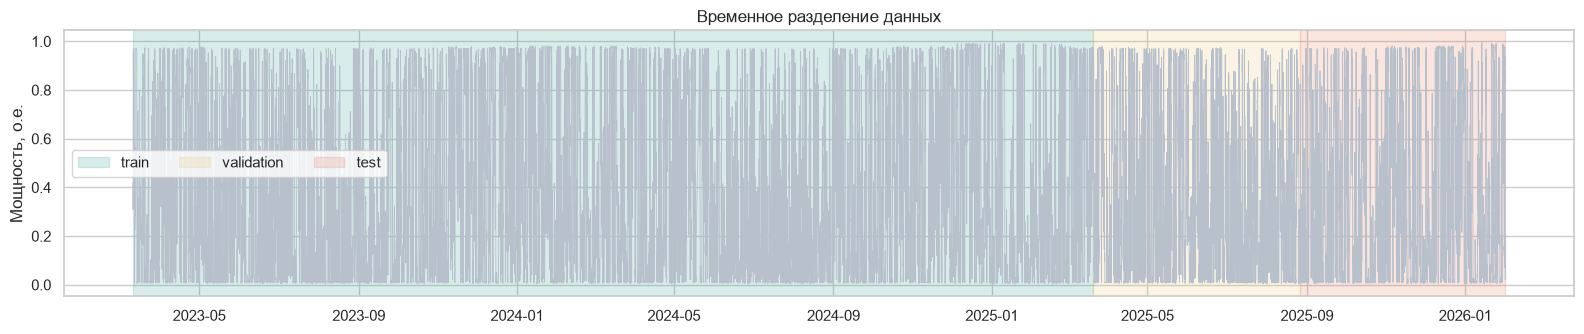

In [11]:
n = len(X)
train_end = int(n * 0.70)
valid_end = int(n * 0.85)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_valid, y_valid = X.iloc[train_end:valid_end], y.iloc[train_end:valid_end]
X_test, y_test = X.iloc[valid_end:], y.iloc[valid_end:]

split_summary = pd.DataFrame({
    "rows": [len(X_train), len(X_valid), len(X_test)],
    "start": [X_train.index.min(), X_valid.index.min(), X_test.index.min()],
    "end": [X_train.index.max(), X_valid.index.max(), X_test.index.max()],
}, index=["train", "validation", "test"])
display(split_summary)

plt.figure(figsize=(16, 3.5))
plt.plot(y.index, y, color="#B8C0CC", lw=0.6)
plt.axvspan(X_train.index.min(), X_train.index.max(), alpha=0.18, color="#2A9D8F", label="train")
plt.axvspan(X_valid.index.min(), X_valid.index.max(), alpha=0.18, color="#E9C46A", label="validation")
plt.axvspan(X_test.index.min(), X_test.index.max(), alpha=0.18, color="#E76F51", label="test")
plt.title("Временное разделение данных")
plt.ylabel("Мощность, о.е.")
plt.legend(ncol=3)
plt.tight_layout()
plt.show()


## 8. Базовые модели и CatBoost

- **Среднее train** — минимальная проверка здравого смысла.
- **Эмпирическая кривая мощности** — медианная мощность по диапазонам ветра.
- **CatBoost** — основная нелинейная модель.


In [12]:
def fit_power_curve(wind, power, bin_width=0.5):
    train_curve = pd.DataFrame({"wind": wind, "power": power}).dropna()
    train_curve["wind_bin"] = (train_curve["wind"] / bin_width).round() * bin_width
    curve = train_curve.groupby("wind_bin")["power"].median().sort_index()
    full_index = np.arange(0, max(30, curve.index.max()) + bin_width, bin_width)
    curve = curve.reindex(full_index).interpolate(limit_direction="both").clip(0, 1)
    return curve


def predict_power_curve(curve, wind):
    return np.interp(
        np.asarray(wind, dtype=float), curve.index.to_numpy(dtype=float), curve.to_numpy(dtype=float)
    )


power_curve = fit_power_curve(X_train["wind_speed"], y_train)

model = CatBoostRegressor(
    iterations=2_000,
    depth=8,
    learning_rate=0.03,
    loss_function="MAE",
    eval_metric="MAE",
    l2_leaf_reg=5,
    random_seed=RANDOM_STATE,
    allow_writing_files=False,
    verbose=100,
)

model.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=150,
    use_best_model=True,
)

predictions = {
    "Среднее train": np.full(len(X_test), y_train.mean()),
    "Кривая мощности": predict_power_curve(power_curve, X_test["wind_speed"]),
    "CatBoost": np.clip(model.predict(X_test), 0, 1),
}

print(f"Лучшая итерация CatBoost: {model.get_best_iteration()}")


0:	learn: 0.2998282	test: 0.2662741	best: 0.2662741 (0)	total: 92.7ms	remaining: 3m 5s
100:	learn: 0.0274153	test: 0.0230357	best: 0.0230357 (100)	total: 646ms	remaining: 12.1s
200:	learn: 0.0196583	test: 0.0165362	best: 0.0165362 (200)	total: 1.21s	remaining: 10.8s
300:	learn: 0.0189474	test: 0.0159712	best: 0.0159712 (300)	total: 1.75s	remaining: 9.89s
400:	learn: 0.0185072	test: 0.0158227	best: 0.0158166 (395)	total: 2.26s	remaining: 9.02s
500:	learn: 0.0180971	test: 0.0157601	best: 0.0157546 (457)	total: 2.83s	remaining: 8.45s
600:	learn: 0.0177440	test: 0.0157023	best: 0.0157018 (599)	total: 3.37s	remaining: 7.85s
700:	learn: 0.0174633	test: 0.0156902	best: 0.0156851 (661)	total: 3.89s	remaining: 7.21s
800:	learn: 0.0171995	test: 0.0156872	best: 0.0156784 (767)	total: 4.38s	remaining: 6.56s
900:	learn: 0.0169421	test: 0.0156901	best: 0.0156737 (828)	total: 4.92s	remaining: 6s
1000:	learn: 0.0166968	test: 0.0157014	best: 0.0156736 (944)	total: 5.47s	remaining: 5.46s
Stopped by over

## 9. Оценка качества на отложенном тесте

`nMAE` выражается в процентах установленной мощности, поскольку цель нормализована в диапазоне 0–1. Метрика `MAPE` не используется: она нестабильна около нулевой выработки.


,MAE,RMSE,"nMAE, % мощности",Bias,R2
CatBoost,0.0206,0.0556,2.0600,0.0099,0.9758
Кривая мощности,0.0240,0.0572,2.4000,0.0110,0.9745
Среднее train,0.3207,0.3587,32.0700,0.0237,-0.0044


Изменение MAE CatBoost относительно лучшей базовой модели: +14.44%


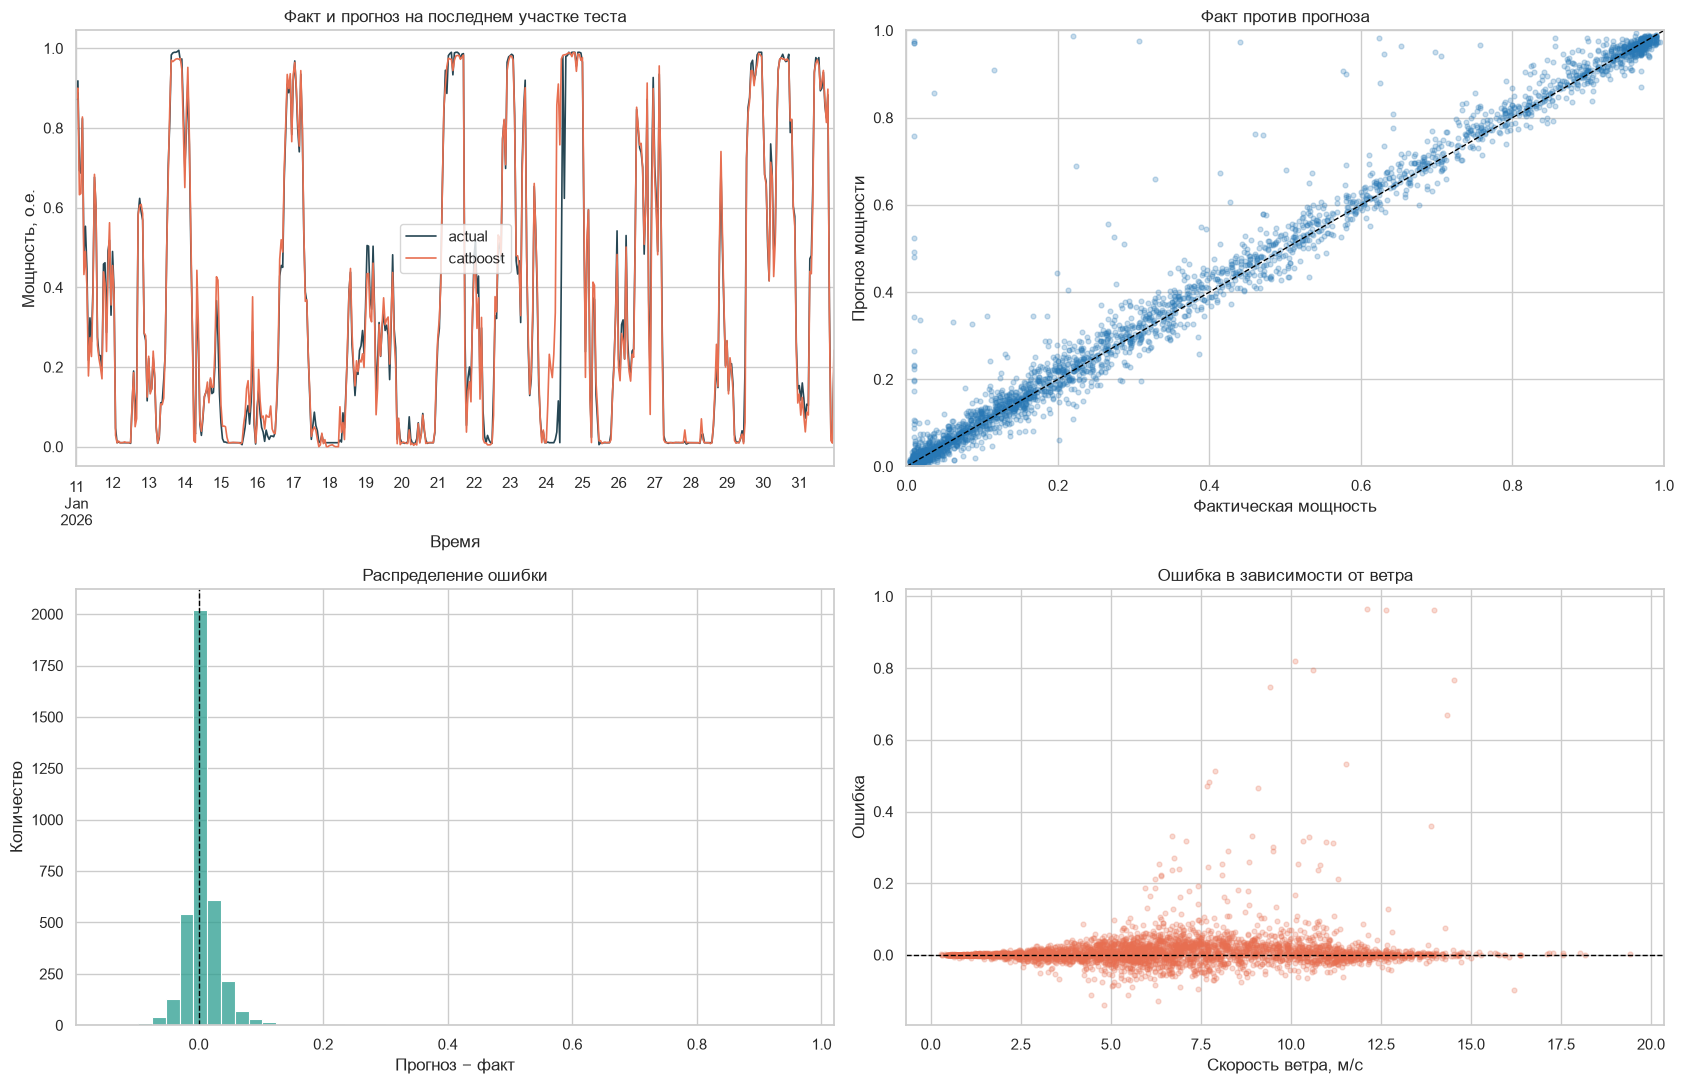

In [13]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5

    return {
        "MAE": mae,
        "RMSE": rmse,
        "nMAE, % мощности": 100 * mae,
        "Bias": float(np.mean(y_pred - y_true)),
        "R2": r2_score(y_true, y_pred),
    }


# Расчёт метрик
metrics = pd.DataFrame({
    name: regression_metrics(y_test, pred)
    for name, pred in predictions.items()
}).T.sort_values("MAE")


# Обычное отображение без pandas.style и jinja2
metrics_display = metrics.copy()

metrics_display["MAE"] = metrics_display["MAE"].round(4)
metrics_display["RMSE"] = metrics_display["RMSE"].round(4)
metrics_display["nMAE, % мощности"] = (
    metrics_display["nMAE, % мощности"].round(2)
)
metrics_display["Bias"] = metrics_display["Bias"].round(4)
metrics_display["R2"] = metrics_display["R2"].round(4)

display(metrics_display)


# Сравнение CatBoost с лучшей базовой моделью
best_baseline_mae = metrics.loc[
    ["Среднее train", "Кривая мощности"],
    "MAE"
].min()

cat_mae = metrics.loc["CatBoost", "MAE"]

if best_baseline_mae > 0:
    improvement = (
        100 * (best_baseline_mae - cat_mae) / best_baseline_mae
    )
    print(
        "Изменение MAE CatBoost относительно "
        f"лучшей базовой модели: {improvement:+.2f}%"
    )
else:
    print("Невозможно рассчитать улучшение: MAE базовой модели равен нулю.")


# Таблица фактических и прогнозных значений
result = pd.DataFrame({
    "actual": y_test,
    "power_curve": predictions["Кривая мощности"],
    "catboost": predictions["CatBoost"],
})

result["error"] = result["catboost"] - result["actual"]


# Визуализация результатов
fig, axes = plt.subplots(2, 2, figsize=(17, 11))

view = result.tail(min(24 * 21, len(result)))

view[["actual", "catboost"]].plot(
    ax=axes[0, 0],
    color=["#264653", "#E76F51"],
    linewidth=1.2,
)

axes[0, 0].set(
    title="Факт и прогноз на последнем участке теста",
    xlabel="Время",
    ylabel="Мощность, о.е.",
)


axes[0, 1].scatter(
    result["actual"],
    result["catboost"],
    alpha=0.25,
    s=12,
    color="#2878B5",
)

axes[0, 1].plot(
    [0, 1],
    [0, 1],
    "--",
    color="black",
    linewidth=1,
)

axes[0, 1].set(
    xlabel="Фактическая мощность",
    ylabel="Прогноз мощности",
    title="Факт против прогноза",
    xlim=(0, 1),
    ylim=(0, 1),
)


sns.histplot(
    result["error"],
    bins=50,
    kde=False,
    ax=axes[1, 0],
    color="#2A9D8F",
)

axes[1, 0].axvline(
    0,
    linestyle="--",
    color="black",
    linewidth=1,
)

axes[1, 0].set(
    title="Распределение ошибки",
    xlabel="Прогноз − факт",
    ylabel="Количество",
)


axes[1, 1].scatter(
    X_test["wind_speed"],
    result["error"],
    alpha=0.25,
    s=12,
    color="#E76F51",
)

axes[1, 1].axhline(
    0,
    linestyle="--",
    color="black",
    linewidth=1,
)

axes[1, 1].set(
    title="Ошибка в зависимости от ветра",
    xlabel="Скорость ветра, м/с",
    ylabel="Ошибка",
)

plt.tight_layout()
plt.show()

## 10. Важность признаков и диагностика по режимам

Диагностика показывает, при каких скоростях ветра и сезонах модель ошибается сильнее.


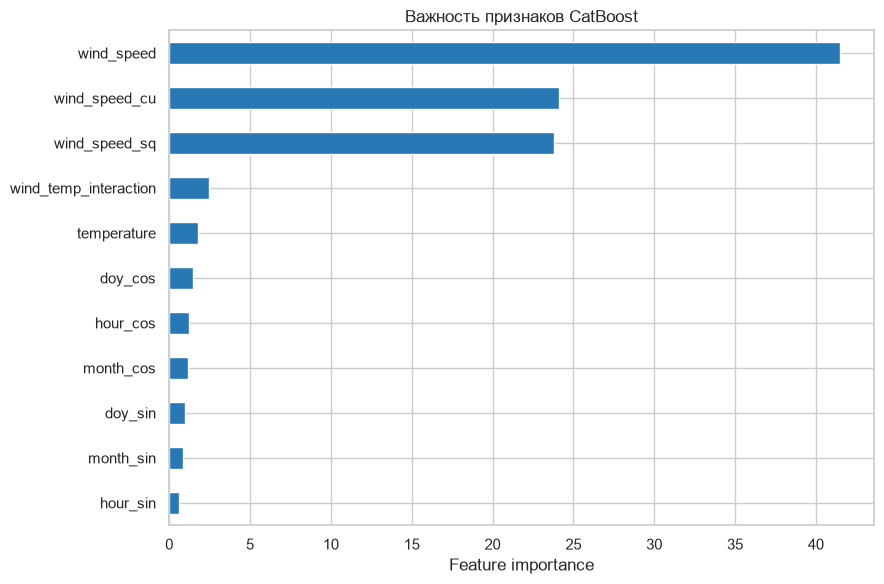

MAE по диапазонам скорости ветра:


,count,mean,median
wind_band,,,
"(-inf, 3.0]",883,0.0026,0.0010
"(3.0, 6.0]",980,0.0178,0.0128
"(6.0, 9.0]",909,0.0345,0.0239
"(9.0, 12.0]",666,0.0284,0.0138
"(12.0, 15.0]",270,0.0242,0.0037
"(15.0, 25.0]",23,0.0074,0.0023


MAE по месяцам тестового периода:


,count,mean,median
month,,,
1,744,0.0223,0.0104
8,122,0.0095,0.0042
9,719,0.0135,0.0074
10,690,0.0199,0.0112
11,720,0.0152,0.0077
12,736,0.0335,0.0115


In [14]:
importance = pd.Series(model.get_feature_importance(), index=feature_names).sort_values()
plt.figure(figsize=(9, 6))
importance.plot(kind="barh", color="#2878B5")
plt.title("Важность признаков CatBoost")
plt.xlabel("Feature importance")
plt.tight_layout()
plt.show()

diagnostics = X_test[["wind_speed"]].copy()
diagnostics["abs_error"] = result["error"].abs()
diagnostics["wind_band"] = pd.cut(
    diagnostics["wind_speed"], bins=[-np.inf, 3, 6, 9, 12, 15, 25, np.inf]
)
diagnostics["month"] = diagnostics.index.month

print("MAE по диапазонам скорости ветра:")
display(diagnostics.groupby("wind_band", observed=True)["abs_error"].agg(["count", "mean", "median"]))

print("MAE по месяцам тестового периода:")
display(diagnostics.groupby("month")["abs_error"].agg(["count", "mean", "median"]))


## 11. Опциональная скользящая валидация

Эта проверка обучает модель несколько раз и поэтому выключена по умолчанию. Включите `RUN_WALK_FORWARD = True` в настройках для более надёжной оценки устойчивости.


In [15]:
if RUN_WALK_FORWARD:
    splitter = TimeSeriesSplit(n_splits=4)
    fold_rows = []

    for fold, (train_idx, valid_idx) in enumerate(splitter.split(X), start=1):
        fold_model = CatBoostRegressor(
            iterations=1_000,
            depth=8,
            learning_rate=0.04,
            loss_function="MAE",
            eval_metric="MAE",
            random_seed=RANDOM_STATE + fold,
            allow_writing_files=False,
            verbose=False,
        )
        fold_model.fit(
            X.iloc[train_idx], y.iloc[train_idx],
            eval_set=(X.iloc[valid_idx], y.iloc[valid_idx]),
            early_stopping_rounds=100,
            verbose=False,
        )
        fold_pred = np.clip(fold_model.predict(X.iloc[valid_idx]), 0, 1)
        fold_rows.append({
            "fold": fold,
            "train_end": X.index[train_idx[-1]],
            "validation_start": X.index[valid_idx[0]],
            "validation_end": X.index[valid_idx[-1]],
            **regression_metrics(y.iloc[valid_idx], fold_pred),
        })

    walk_forward_results = pd.DataFrame(fold_rows).set_index("fold")
    display(walk_forward_results)
    print("Средние метрики:")
    display(walk_forward_results.select_dtypes("number").mean().to_frame("mean"))
else:
    print("Скользящая валидация отключена. Установите RUN_WALK_FORWARD = True для запуска.")


Скользящая валидация отключена. Установите RUN_WALK_FORWARD = True для запуска.


## 12. Финальное обучение и сохранение артефактов

После финального теста модель переобучается на train + validation. Тест остаётся независимым и не используется для настройки параметров. Сохраняются модель, список признаков, метаданные, кривая мощности и тестовые прогнозы.


In [16]:
best_iterations = max(50, model.get_best_iteration() + 1)
X_train_final = pd.concat([X_train, X_valid])
y_train_final = pd.concat([y_train, y_valid])

final_model = CatBoostRegressor(
    iterations=best_iterations,
    depth=8,
    learning_rate=0.03,
    loss_function="MAE",
    l2_leaf_reg=5,
    random_seed=RANDOM_STATE,
    allow_writing_files=False,
    verbose=False,
)
final_model.fit(X_train_final, y_train_final, verbose=False)

final_test_pred = np.clip(final_model.predict(X_test), 0, 1)
final_metrics = regression_metrics(y_test, final_test_pred)

model_path = ARTIFACT_DIR / "wind_power_catboost.cbm"
metadata_path = ARTIFACT_DIR / "metadata.json"
curve_path = ARTIFACT_DIR / "empirical_power_curve.csv"
predictions_path = ARTIFACT_DIR / "test_predictions.csv"
hourly_path = ARTIFACT_DIR / "clean_hourly_data.csv"

final_model.save_model(model_path)
power_curve.rename("normalized_power").to_csv(curve_path, index_label="wind_speed")

saved_predictions = pd.DataFrame({
    "datetime": X_test.index,
    "actual_power": y_test.to_numpy(),
    "predicted_power": final_test_pred,
})
if INSTALLED_CAPACITY_MW is not None:
    saved_predictions["predicted_energy_mwh"] = (
        saved_predictions["predicted_power"] * float(INSTALLED_CAPACITY_MW)
    )
saved_predictions.to_csv(predictions_path, index=False)

hourly.to_csv(hourly_path, index_label="datetime")

metadata = {
    "target": "target_power",
    "target_definition": "hourly mean normalized active power",
    "features": feature_names,
    "train_start": str(X_train_final.index.min()),
    "train_end": str(X_train_final.index.max()),
    "test_start": str(X_test.index.min()),
    "test_end": str(X_test.index.max()),
    "installed_capacity_mw": INSTALLED_CAPACITY_MW,
    "best_iterations": int(best_iterations),
    "test_metrics": {k: float(v) for k, v in final_metrics.items()},
    "note": "Observed weather was used as a proxy. Use archived issued forecasts for operational backtesting.",
}
metadata_path.write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")

print("Финальная тестовая оценка:")
display(pd.Series(final_metrics, name="value").to_frame())
print("Сохранено:")
for path in [model_path, metadata_path, curve_path, predictions_path, hourly_path]:
    print(" •", path.resolve())


Финальная тестовая оценка:


,value
MAE,0.0204
RMSE,0.0556
"nMAE, % мощности",2.0422
Bias,0.0101
R2,0.9759


Сохранено:
 • C:\python_projects\hack-292e04fe-neurohub\model_artifacts\wind_power_catboost.cbm
 • C:\python_projects\hack-292e04fe-neurohub\model_artifacts\metadata.json
 • C:\python_projects\hack-292e04fe-neurohub\model_artifacts\empirical_power_curve.csv
 • C:\python_projects\hack-292e04fe-neurohub\model_artifacts\test_predictions.csv
 • C:\python_projects\hack-292e04fe-neurohub\model_artifacts\clean_hourly_data.csv


## 13. Функция применения модели к будущему прогнозу погоды

Входной файл должен содержать почасовые `datetime`, `wind_speed` и `temperature`. В промышленной системе это будут данные внешнего погодного API на следующие 24–48 часов.


In [17]:
def forecast_from_weather(trained_model, future_weather, installed_capacity_mw=None):
    '''
    future_weather: DataFrame с колонками datetime, wind_speed, temperature.
    Возвращает почасовой прогноз нормализованной мощности и, при наличии мощности ВЭС, МВт·ч.
    '''
    required = {"datetime", "wind_speed", "temperature"}
    absent = required.difference(future_weather.columns)
    if absent:
        raise ValueError(f"В future_weather отсутствуют столбцы: {sorted(absent)}")

    future = future_weather.copy()
    future["datetime"] = pd.to_datetime(future["datetime"], errors="coerce")
    future["wind_speed"] = pd.to_numeric(future["wind_speed"], errors="coerce")
    future["temperature"] = pd.to_numeric(future["temperature"], errors="coerce")
    future = future.dropna(subset=["datetime"]).sort_values("datetime").set_index("datetime")
    future = future[["wind_speed", "temperature"]].resample("1h").mean()

    if future[["wind_speed", "temperature"]].isna().any().any():
        bad_times = future.index[future[["wind_speed", "temperature"]].isna().any(axis=1)]
        raise ValueError(f"В прогнозе погоды есть пропуски: {list(bad_times[:10])}")

    future_X = make_features(future)
    prediction = np.clip(trained_model.predict(future_X[feature_names]), 0, 1)

    output = pd.DataFrame({
        "datetime": future.index,
        "forecast_normalized_power": prediction,
    })
    if installed_capacity_mw is not None:
        output["forecast_energy_mwh"] = prediction * float(installed_capacity_mw)
    return output


# Пустой шаблон на 48 часов для подключения следующей задачи — погодного API.
next_hour = hourly.index.max().floor("h") + pd.Timedelta(hours=1)
future_template = pd.DataFrame({
    "datetime": pd.date_range(next_hour, periods=48, freq="1h"),
    "wind_speed": np.nan,
    "temperature": np.nan,
})
template_path = ARTIFACT_DIR / "future_weather_template_48h.csv"
future_template.to_csv(template_path, index=False)

display(future_template.head())
print("Шаблон сохранён:", template_path.resolve())

# Пример после заполнения шаблона погодой:
# future_weather = pd.read_csv(template_path)
# forecast_48h = forecast_from_weather(final_model, future_weather, INSTALLED_CAPACITY_MW)
# display(forecast_48h)

,datetime,wind_speed,temperature
0,2026-02-01 00:00:00,NaN,NaN
1,2026-02-01 01:00:00,NaN,NaN
2,2026-02-01 02:00:00,NaN,NaN
3,2026-02-01 03:00:00,NaN,NaN
4,2026-02-01 04:00:00,NaN,NaN


Шаблон сохранён: C:\python_projects\hack-292e04fe-neurohub\model_artifacts\future_weather_template_48h.csv


In [18]:
import requests
import pandas as pd

LATITUDE = 56.742815
LONGITUDE = 61.084327
TIMEZONE = "Asia/Yekaterinburg"

url = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "hourly": [
        "temperature_2m",
        "wind_speed_100m",
        "wind_direction_100m",
        "wind_gusts_10m",
        "surface_pressure",
    ],
    "wind_speed_unit": "ms",
    "forecast_hours": 48,
    "timezone": "auto",
}

response = requests.get(url, params=params, timeout=30)
response.raise_for_status()

weather_json = response.json()

future_weather = pd.DataFrame({
    "datetime": pd.to_datetime(weather_json["hourly"]["time"]),
    "wind_speed": weather_json["hourly"]["wind_speed_100m"],
    "temperature": weather_json["hourly"]["temperature_2m"],
})

display(future_weather.head())

,datetime,wind_speed,temperature
0,2026-09-23 15:00:00,2.5300,21.9000
1,2026-09-23 16:00:00,3.4300,21.4000
2,2026-09-23 17:00:00,4.3900,20.6000
3,2026-09-23 18:00:00,5.0900,18.7000
4,2026-09-23 19:00:00,4.9600,15.8000


In [19]:
INSTALLED_CAPACITY_MW = 50.0

forecast_48h = forecast_from_weather(
    trained_model=final_model,
    future_weather=future_weather,
    installed_capacity_mw=INSTALLED_CAPACITY_MW,
)

# Добавляем мощность в МВт
forecast_48h["forecast_power_mw"] = (
    forecast_48h["forecast_normalized_power"]
    * INSTALLED_CAPACITY_MW
)

# Для почасового интервала численное значение энергии совпадает с MW × 1 час
forecast_48h["forecast_energy_mwh"] = (
    forecast_48h["forecast_power_mw"] * 1
)

display(forecast_48h)

,datetime,forecast_normalized_power,forecast_energy_mwh,forecast_power_mw
0,2026-09-23 15:00:00,0.0139,0.6934,0.6934
1,2026-09-23 16:00:00,0.0425,2.1252,2.1252
2,2026-09-23 17:00:00,0.0959,4.7970,4.7970
3,2026-09-23 18:00:00,0.1509,7.5467,7.5467
4,2026-09-23 19:00:00,0.1343,6.7136,6.7136
5,2026-09-23 20:00:00,0.1177,5.8842,5.8842
6,2026-09-23 21:00:00,0.1286,6.4294,6.4294
7,2026-09-23 22:00:00,0.1404,7.0223,7.0223
8,2026-09-23 23:00:00,0.0829,4.1439,4.1439
9,2026-09-24 00:00:00,0.0839,4.1943,4.1943


In [20]:
from pathlib import Path

OUTPUT_DIR = Path.cwd() / "model_artifacts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

forecast_path = OUTPUT_DIR / "forecast_48h.csv"

forecast_48h.to_csv(
    forecast_path,
    index=False,
    encoding="utf-8-sig",
)

print("Итоговый прогноз:", forecast_path.resolve())

Итоговый прогноз: C:\python_projects\hack-292e04fe-neurohub\model_artifacts\forecast_48h.csv


In [ ]:
## Тестирование

In [21]:
test_prediction = np.clip(
    final_model.predict(X_test),
    0,
    1,
)

errors = test_prediction - y_test.to_numpy()
absolute_errors = np.abs(errors)

mae = mean_absolute_error(y_test, test_prediction)
rmse = mean_squared_error(y_test, test_prediction) ** 0.5
r2 = r2_score(y_test, test_prediction)
bias = errors.mean()

# Условный аналог accuracy для регрессии:
# доля прогнозов с ошибкой не более 5 и 10 процентных пунктов
accuracy_5 = np.mean(absolute_errors <= 0.05)
accuracy_10 = np.mean(absolute_errors <= 0.10)

final_quality = pd.DataFrame({
    "Метрика": [
        "MAE",
        "RMSE",
        "nMAE",
        "R²",
        "Bias",
        "Точность в пределах ±5 п.п.",
        "Точность в пределах ±10 п.п.",
    ],
    "Значение": [
        mae,
        rmse,
        mae * 100,
        r2,
        bias,
        accuracy_5 * 100,
        accuracy_10 * 100,
    ],
    "Единица": [
        "о.е.",
        "о.е.",
        "%",
        "коэффициент",
        "о.е.",
        "%",
        "%",
    ],
})

display(final_quality)

,Метрика,Значение,Единица
0,MAE,0.0204,о.е.
1,RMSE,0.0556,о.е.
2,nMAE,2.0422,%
3,R²,0.9759,коэффициент
4,Bias,0.0101,о.е.
5,Точность в пределах ±5 п.п.,92.2005,%
6,Точность в пределах ±10 п.п.,98.0702,%
